# **Machine Learning–Driven Churn Prediction and Risk-Based Segmentation in E-Commerce**

## *Research Question:*
### *How can machine learning–driven churn prediction models be integrated into a risk-based segmentation framework to design targeted retention strategies that maximise customer lifetime value in e-commerce?*

#### *This notebook implements the modelling pipeline for an e-commerce churn analysis project. It covers data preparation, model training and evaluation, churn risk scoring, value proxy construction and behavioural/RFM-style clustering, in order to support a risk-based segmentation framework for targeted retention strategies*

#### *This project aims to* 
#### *(1) build and compare several machine learning models for predicting customer churn using behavioural, transactional, demographic and experiential features,* 
#### *(2) engineer segmentation metrics, including RFM-style and behavioural clusters,* 
#### *(3) convert churn probabilities into interpretable low-, medium- and high-risk segments, and* 
#### *(4) combine risk, value proxies and clusters to identify priority customer groups for targeted, CLV-oriented retention strategies.*

### Imports and setup

In [5]:
# Data handling (import libraries)
# importing pandas is used for cleaning and manipulating the tabular data
import pandas as pd
# importing numpy is for the numerical operations
import numpy as np
# Visualisation libraries 
import matplotlib.pyplot as plt
import seaborn as sns

# Model evaluation and splitting 
#importing for train and split data for testing 
from sklearn.model_selection import train_test_split

# data Preprocessing
# to encode the categorical values and to scale numerical values
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# to apply different preprocessing for numerical and categorical columns
from sklearn.compose import ColumnTransformer
# to make in a single pipe (single flow)
from sklearn.pipeline import Pipeline

# evaluation metrics for the classification models 
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, # to classify the performance metrics
    f1_score, roc_auc_score, confusion_matrix # model evaluation
)

# modelling 
from sklearn.linear_model import LogisticRegression #logistic regression (basic model)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # random forest and gradient boosting

# to find the missing values 
from sklearn.impute import SimpleImputer
# K-means cluster algorithm
from sklearn.cluster import KMeans   

# scaling for clustering 
from sklearn.preprocessing import StandardScaler
# used for cross-validation
from sklearn.model_selection import cross_val_score, StratifiedKFold

#### Together, these libraries gave me everything I needed to build the end-to-end pipeline for churn prediction, risk scoring and segmentation, in line with my research question and project objectives.

# Data loading and initial checks 

In [8]:
# to load the dataset
df = pd.read_csv("Downloads\ecommerce_churn_dataset.csv")

<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:2: SyntaxWarning: invalid escape sequence '\e'
C:\Users\rubam\AppData\Local\Temp\ipykernel_29680\3958100275.py:2: SyntaxWarning: invalid escape sequence '\e'
  df = pd.read_csv("Downloads\ecommerce_churn_dataset.csv")


#### I loaded the dataset into a pandas DataFrame using pd.read_csv(). Each row represented a customer and each column represented a behavioural, transactional, demographic or experiential attribute, including the target variable Churn. Having the data in a DataFrame (df) gave me a structured format for all later cleaning, preprocessing and model training steps in the churn prediction pipeline.







In [10]:
# to see the data is uploaded correctly
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


#### I used df.head() to display the first five rows of the DataFrame. This quick preview let me check that the data had loaded correctly, see the column names and get an initial sense of the values and formats before starting any cleaning or modelling.







In [12]:
# to see the overview of the cloumns and datatypes 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

#### I used df.info() to obtain a concise summary of the dataset, including the number of rows, non-null counts per column and each column’s data type (e.g. integer, float, object). This helped me confirm the overall shape of the data, see where missing values occurred and check that Churn and the numerical features were in suitable formats for preprocessing and modelling.








In [14]:
# to find the missing values
df.isna().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

#### I ran df.isna().sum() to count the number of missing (NaN) values in each column. This showed me which variables, such as Tenure, WarehouseToHome, HourSpendOnApp, OrderAmountHikeFromlastYear, CouponUsed, OrderCount and DaySinceLastOrder, had gaps that needed to be handled. Understanding this pattern of missingness guided my choice of imputation strategies in the preprocessing pipeline.









In [16]:
# to display the column names in the dataframe
df.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

#### I used df.columns to list all variable names in the dataset. This let me verify that the expected features were present (for example CustomerID, Churn, Tenure, OrderCount, CashbackAmount, DaySinceLastOrder, SatisfactionScore and the categorical attributes) and helped me decide which columns to treat as numerical features, categorical features, the target variable or identifiers for later modelling steps.


## Feature defnition and preprocessing 

In [19]:
# to ensure that the churn is coded as 0 / 1 (yes/ no) 
if df['Churn'].dtype == 'object':
    print("Mapping Churn from text to 0/1...")
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})


#### At this stage, I checked the data type of the Churn column. When Churn was stored as text labels (e.g. "Yes" and "No"), I mapped it to numeric values where "No" became 0 and "Yes" became 1. This conversion was required because scikit-learn’s classification models expected a numeric target, and it also kept the interpretation of predictions and metrics (precision, recall and AUC for the positive class) consistent throughout my analysis.

In [21]:
# to predict the target 
target = "Churn"

# numerical inputs
numeric_features = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount",
]

# categorical inputs
categorical_features = [
    "PreferredLoginDevice",
    "CityTier",
    "PreferredPaymentMode",
    "Gender",
    "PreferedOrderCat",
    "MaritalStatus",
    "Complain",
]


#### At this point, I set Churn as the target variable to be predicted (0 = non-churner, 1 = churner), and I split the remaining columns into:
#### - Numerical features (e.g. Tenure, OrderCount, DaySinceLastOrder, CashbackAmount), which stored continuous or count values.
#### - Categorical features (e.g. PreferredLoginDevice, PreferredPaymentMode, MaritalStatus, Complain), which stored discrete categories.
#### This separation was needed so I could apply appropriate preprocessing later: scaling for numerical variables and one-hot encoding for categorical variables, before training the churn prediction models.

In [23]:
# to fill the numerical values
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), # to fill NaNs in numeric columns
    ("scaler", StandardScaler()) # sacles to 0 and 1
])

# to fill the categorical values 
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), # to fill the mising values the most frequent category
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# to apply both the numerical and categorical values to the right columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

#### In this step, I prepared the raw dataset for modelling. I imputed numerical features with the median and scaled them with StandardScaler so missing values were handled and all numeric variables were on a comparable scale, which stabilised training and made model comparison fair. I imputed categorical features with the most frequent category and one-hot encoded them so they could be used as numeric inputs without losing category information. I then used a ColumnTransformer to combine these steps into a single feature matrix reused by all models. This consistent preprocessing was necessary to produce reliable churn probabilities and to support the risk bands and segmentation framework defined in my research question and objectives.

## Train–test split

In [26]:
# Y is the target (churn), and X is the predictors
X = df[numeric_features + categorical_features]
y = df[target]

# to train and test split (80% and 20%) 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y 
)

X_train.shape, X_test.shape


((4504, 18), (1126, 18))

#### At this point, I created the full feature matrix X from the selected numerical and categorical predictors and set y to the churn label. I then split the data into a training set (80%) and a test set (20%) using train_test_split with stratification on y so that the churn/non-churn ratio was preserved. This separation let me train the models on one portion of the data and evaluate them on unseen data, which was essential for honest performance estimates when comparing Logistic Regression, Random Forest and Gradient Boosting, and for ensuring that the churn probabilities later used for risk bands and segmentation were not overfitted.

## Model training and comparison (Logistic, Random Forest, Gradient Boosting)

In [29]:
# Logistic regression model 

# to pipeline the LR
log_reg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor), #preprocessing and the linear model
    ("clf", LogisticRegression(max_iter=1000))
])

# to train and test the models
log_reg_pipe.fit(X_train, y_train)

y_pred_lr = log_reg_pipe.predict(X_test)  # to predict the class 
y_proba_lr = log_reg_pipe.predict_proba(X_test)[:, 1] # to know the churn probablity 


# printing the evaluation metrics to know the values 
print("=== Logistic Regression ===")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1       :", f1_score(y_test, y_pred_lr))
print("AUC      :", roc_auc_score(y_test, y_proba_lr))


=== Logistic Regression ===
Accuracy : 0.88898756660746
Precision: 0.7480916030534351
Recall   : 0.5157894736842106
F1       : 0.6105919003115264
AUC      : 0.8866228070175439


#### I used Logistic Regression as a simple, well-known baseline for churn prediction. It showed how well a standard linear classifier could separate churners from non-churners after the common preprocessing pipeline. The test metrics (Accuracy, Precision, Recall, F1 and ROC AUC) gave me a reference level of performance that the ensemble models (Random Forest and Gradient Boosting) were expected to improve on, enabling a fair comparison before choosing the best model for generating churn probabilities for the risk-based segmentation framework.

In [31]:
# Random Forest Model
# to pipeline the RF
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor), # peprocessing and ensemble of the trees.
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42))
])

# to train and test the models
rf_pipe.fit(X_train, y_train)

y_pred_rf = rf_pipe.predict(X_test) # to predict the class 
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1] # to know the churn probablity 

# printing the evaluation metrics to know the values 
print("=== Random Forest ===")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1       :", f1_score(y_test, y_pred_rf))
print("AUC      :", roc_auc_score(y_test, y_proba_rf))


=== Random Forest ===
Accuracy : 0.9795737122557726
Precision: 0.9883040935672515
Recall   : 0.8894736842105263
F1       : 0.9362880886426593
AUC      : 0.9989316239316239


#### I used Random Forest as a non-linear ensemble model to see whether it could outperform the Logistic Regression baseline. Because it combined many decision trees, it was able to capture more complex interactions between the churn drivers. Using the same preprocessing and train–test split, its Accuracy, Precision, Recall, F1 and ROC AUC were directly comparable to the baseline, helping me identify a stronger model for generating churn probabilities for the risk-based segmentation framework.

In [33]:
# Gradient Boosting
# pipeling the GB
gb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor), #preprocessing and the boosting model 
    ("clf", GradientBoostingClassifier(random_state=42))
])

# to train and test the models
gb_pipe.fit(X_train, y_train)

y_pred_gb = gb_pipe.predict(X_test) # to predict the class 
y_proba_gb = gb_pipe.predict_proba(X_test)[:, 1] # to know the churn probablity 


# printing the evaluation metrics to know the values 
print("=== Gradient Boosting ===")
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1       :", f1_score(y_test, y_pred_gb))
print("AUC      :", roc_auc_score(y_test, y_proba_gb))


=== Gradient Boosting ===
Accuracy : 0.9209591474245116
Precision: 0.8344370860927153
Recall   : 0.6631578947368421
F1       : 0.7390029325513197
AUC      : 0.9482849752586594


#### I added Gradient Boosting as a second ensemble model to test whether a boosting approach could match or exceed Random Forest and the Logistic Regression baseline. It built trees sequentially, focusing on correcting previous errors, which could improve predictive accuracy on complex churn patterns. Using the same preprocessing and train–test split, its Accuracy, Precision, Recall, F1 and ROC AUC were directly comparable to the other models, allowing me to complete the performance comparison before selecting the best model for churn probability estimation in the risk-based segmentation framework.

In [35]:
# to evaluate the three models 
results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision": precision_score(y_test, y_pred_lr),
        "Recall": recall_score(y_test, y_pred_lr),
        "F1": f1_score(y_test, y_pred_lr),
        "AUC": roc_auc_score(y_test, y_proba_lr),
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1": f1_score(y_test, y_pred_rf),
        "AUC": roc_auc_score(y_test, y_proba_rf),
    },
    {
        "Model": "Gradient Boosting",
        "Accuracy": accuracy_score(y_test, y_pred_gb),
        "Precision": precision_score(y_test, y_pred_gb),
        "Recall": recall_score(y_test, y_pred_gb),
        "F1": f1_score(y_test, y_pred_gb),
        "AUC": roc_auc_score(y_test, y_proba_gb),
    },
]


#### In this block, I collected the test-set metrics for all three models—Logistic Regression, Random Forest and Gradient Boosting—into a single results list. For each model, I stored Accuracy, Precision, Recall, F1 and ROC AUC so they could be converted into a summary table (results_df). This side-by-side view made it easy to see which model performed best and supported my selection of the most suitable model for generating churn probabilities for the risk-based segmentation framework.


In [37]:
# used for creating the table to evaluate the  three models 
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.888988,0.748092,0.515789,0.610592,0.886623
1,Random Forest,0.979574,0.988304,0.889474,0.936288,0.998932
2,Gradient Boosting,0.920959,0.834437,0.663158,0.739003,0.948285


#### In this step, I converted the metrics list into a DataFrame (results_df) so the three models could be compared in one table. Using Accuracy, Precision, Recall, F1 and ROC AUC on the same test set, Random Forest achieved the highest ROC AUC and F1-score, with balanced Precision and Recall, and therefore outperformed both Logistic Regression and Gradient Boosting. Based on this comparison, I selected Random Forest as the best model for churn prediction and used it in the rest of the analysis to generate churn probabilities for the risk-based segmentation framework.

## Best-model evaluation (confusion matrix)

In [40]:
# Random Forest is the best model 

# Use Random Forest as the best model
best_pipe = rf_pipe
best_name = "Random Forest"

# to make sure the model is fitted in the training data
best_pipe.fit(X_train, y_train)

# to do the Prediction in test set
y_pred_best = best_pipe.predict(X_test)
y_proba_best = best_pipe.predict_proba(X_test)[:, 1] 

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
cm

array([[934,   2],
       [ 21, 169]], dtype=int64)

#### Since Random Forest performed best in the comparison table, I chose it as the final churn model (best_pipe). I refitted the pipeline on the training data and used it to predict both class labels and churn probabilities on the test set. The confusion matrix (cm) then showed how many customers were correctly and incorrectly classified as churners and non-churners (TN, FP, FN, TP). This step helped me understand the error types of the selected model (especially missed churners vs false alarms) and justified using its churn probabilities as the basis for the later risk-band and segmentation analysis.

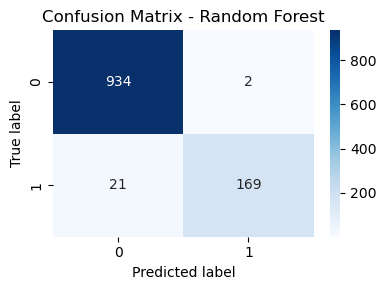

In [42]:
# plotting the confusion matrix 
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.show()

#### I then plotted the confusion matrix for the chosen Random Forest model. The heatmap showed the counts of true negatives, false positives, false negatives and true positives, making it easy to see how often the model correctly identified churners and non-churners and where it made mistakes. This visual helped me interpret the trade-off between catching churners and avoiding false alarms, and it supported the evaluation of the final model before using its probabilities for risk banding and segmentation.


In [44]:
# to extract the TN, FP, FN, TP and to put into the table
TN, FP, FN, TP = cm.ravel()

cm_df = pd.DataFrame(
    [[TN, FP],
     [FN, TP]],
    index=["Actual: No churn", "Actual: Churn"],
    columns=["Predicted: No churn", "Predicted: Churn"]
)

cm_df

,Predicted: No churn,Predicted: Churn
Actual: No churn,934,2
Actual: Churn,21,169


#### Next, I unpacked the confusion matrix into true negatives (TN), false positives (FP), false negatives (FN) and true positives (TP) and arranged them in a clear table (cm_df) with actual vs predicted churn labels. This tabular view made it easier to report and interpret the model’s errors (especially false negatives, i.e. missed churners) in the dissertation and to link the classification performance of the chosen Random Forest model to the potential business impact of churn.

## Churn probabilities and risk bands (Low/Medium/High)

In [47]:
# Using Random Forest as the best model
best_pipe = rf_pipe

# Fitting the best model on the dataset
best_pipe.fit(X, y)

# predicting the churn probability
df["churn_proba"] = best_pipe.predict_proba(X)[:, 1]

# 2. Risk bands
conditions = [
    df["churn_proba"] <= 0.33, # low churn 
    (df["churn_proba"] > 0.33) & (df["churn_proba"] <= 0.66), # medium churn 
    df["churn_proba"] > 0.66, # high churn 
]
choices = ["Low", "Medium", "High"]

# to display it as a table
df["risk_band"] = np.select(conditions, choices)

df[["CustomerID", "Churn", "churn_proba", "risk_band"]].head()


,CustomerID,Churn,churn_proba,risk_band
0,50001,1,0.925,High
1,50002,1,0.955,High
2,50003,1,0.960,High
3,50004,1,0.900,High
4,50005,1,0.850,High


#### I then fitted the final Random Forest model on the full dataset to generate a churn probability (churn_proba) for each customer. I binned these probabilities into three risk bands—Low (≤ 0.33), Medium (0.33–0.66) and High (> 0.66)—stored in risk_band. This converted continuous model outputs into clear, actionable risk categories and directly supported the creation of a risk-based segmentation layer that I later combined with value and cluster information for retention strategy design.

risk_band
Low       83.161634
High      16.820604
Medium     0.017762
Name: proportion, dtype: float64


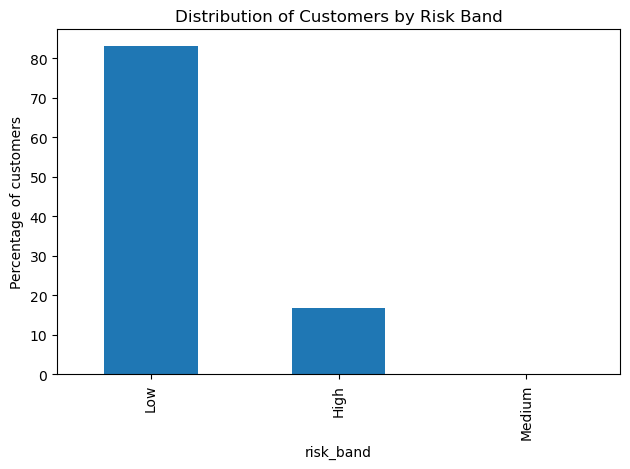

In [49]:
# to calculate the percentage of the cx in each risk band 
risk_counts = df["risk_band"].value_counts(normalize=True) * 100
print(risk_counts)

# to plot the bar chart for distribution
risk_counts.plot(kind="bar")
plt.ylabel("Percentage of customers")
plt.title("Distribution of Customers by Risk Band")
plt.tight_layout()
plt.show()

#### In this step, I calculated the percentage of customers in each risk band (Low, Medium, High) and visualised it with a bar chart. The output showed that most customers fell into the Low-risk group, with a smaller share in High risk and very few in Medium risk. This helped me interpret the class balance of the risk bands, highlighted where the retention focus might be largest (High-risk minority vs Low-risk majority), and provided context for later analysis that combined risk with value and cluster segments.

## K-Means clustering (RFM + behaviour)

NaNs before imputation:
 DaySinceLastOrder              307
OrderCount                     258
CashbackAmount                   0
HourSpendOnApp                 255
SatisfactionScore                0
CouponUsed                     256
OrderAmountHikeFromlastYear    265
dtype: int64


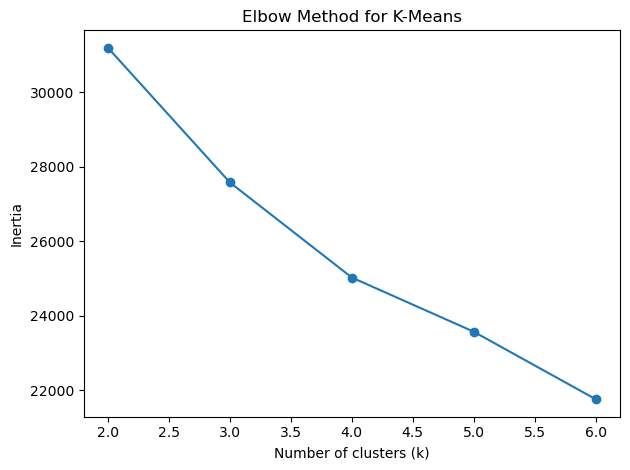

,CustomerID,cluster,risk_band
0,50001,0,High
1,50002,0,High
2,50003,0,High
3,50004,1,High
4,50005,0,High


In [52]:
# to do the recency, frequency and monetary proxy
# Features used for clustering
cluster_features = [
    "DaySinceLastOrder",          # Recency
    "OrderCount",                 # Frequency
    "CashbackAmount",             # Monetary proxy
    "HourSpendOnApp",
    "SatisfactionScore",
    "CouponUsed",
    "OrderAmountHikeFromlastYear",
]

# creating the dataframe only for the clustering features
cluster_df = df[cluster_features].copy()

# Checking for the missing values in the clustering dataframe
print("NaNs before imputation:\n", cluster_df.isna().sum())

# imputing numeric missing values with the median in the clustering dataframe
imputer = SimpleImputer(strategy="median")
cluster_imputed = imputer.fit_transform(cluster_df)

# Scaling for the K-Means
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_imputed)

# using the elbow method to choose k
inertias = []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(cluster_scaled)
    inertias.append(km.inertia_)

# to plot inertia vs number of clusters to visually choose K
plt.plot(K_range, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.tight_layout()
plt.show()

# Choosing the k after looking at elbow method k=4 as an example
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
df["cluster"] = kmeans.fit_predict(cluster_scaled)

df[["CustomerID", "cluster", "risk_band"]].head()

#### In this block, I built customer segments using RFM-style and behavioural features. I extracted DaySinceLastOrder (recency), OrderCount (frequency), CashbackAmount and OrderAmountHikeFromlastYear (monetary proxies), together with HourSpendOnApp, SatisfactionScore and CouponUsed, into cluster_df. I imputed missing values with the median and standardised all features before applying K-Means. I used the elbow method (k = 2–6) to inspect inertia and selected k=4 as a reasonable balance between simplicity and separation. Each customer was then assigned a cluster label, which I viewed alongside risk_band. This delivered the behavioural/RFM segmentation and provided the cluster layer that I later combined with churn risk and value bands in the final risk-based retention framework.

In [54]:
# creating a clustering table with the average values of the key features 
cluster_profile = df.groupby("cluster").agg({
    "DaySinceLastOrder": "mean",
    "OrderCount": "mean",
    "CashbackAmount": "mean",
    "HourSpendOnApp": "mean",
    "SatisfactionScore": "mean",
    "CouponUsed": "mean",
    "OrderAmountHikeFromlastYear": "mean",
    "churn_proba": "mean",
}).round(3)

# to display the cluster profile 
cluster_profile


,DaySinceLastOrder,OrderCount,CashbackAmount,HourSpendOnApp,SatisfactionScore,CouponUsed,OrderAmountHikeFromlastYear,churn_proba
cluster,,,,,,,,
0,3.016,1.656,150.773,2.493,3.030,0.884,13.858,0.194
1,3.608,2.191,165.604,3.431,3.079,1.439,18.576,0.193
2,8.402,9.016,198.568,3.012,3.168,5.321,15.411,0.152
3,7.476,3.056,249.725,2.943,3.049,1.712,14.659,0.077


#### In this step, I summarised each K-Means cluster by calculating the mean of key RFM-style and behavioural features, plus the average churn probability, creating the cluster_profile table. For every cluster, I showed typical recency (DaySinceLastOrder), frequency (OrderCount), monetary proxies (CashbackAmount, OrderAmountHikeFromlastYear), app usage, satisfaction, coupon usage and churn risk. These profiles described how segments differed in behaviour and risk and gave me an interpretable basis for linking specific clusters to tailored retention strategies in line with my research question.

In [56]:
# to create the table displaying the percentage of the risk band 
risk_by_cluster = pd.crosstab(
    df["cluster"],
    df["risk_band"],
    normalize="index"
).round(3) * 100   # convert to %

#to display the table 
risk_by_cluster

risk_band,High,Low,Medium
cluster,,,
0,19.2,80.8,0.0
1,19.1,80.9,0.0
2,15.1,84.9,0.0
3,7.6,92.3,0.1


#### I then created a crosstab (risk_by_cluster) showing, for each cluster, the percentage of customers in each churn risk band (Low, Medium, High). I normalised rows so each cluster summed to 100%, making it easy to see which segments were dominated by high-risk or low-risk customers. This linked the behavioural/RFM clusters to churn risk and helped me identify which segments should be prioritised for targeted retention actions in the risk-based framework.

In [58]:
# to define the 5-fold cross-validation strategy 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# to run the classified strategy using the AUC is the most relevant metric for churn
cv_auc_scores = cross_val_score(
    rf_pipe, # random forest pipeline
    X,  # feature mix 
    y,  # churn labels
    cv=cv, # cross-validation strategy
    scoring="roc_auc"
)

# to display the scores
print("Cross-validated AUC scores:", cv_auc_scores)
print("Mean AUC:", cv_auc_scores.mean())
print("Std AUC :", cv_auc_scores.std())

Cross-validated AUC scores: [0.99324112 0.98596772 0.99214181 0.99201267 0.99147905]
Mean AUC: 0.9909684753917467
Std AUC : 0.002565157534944293


#### Finally, I performed 5-fold stratified cross-validation on the Random Forest pipeline using ROC AUC as the scoring metric. Stratification preserved the churn/non-churn balance in each fold, and AUC was chosen because it measured how well the model ranked churners above non-churners, which is crucial for risk-based actions. The mean and standard deviation of the AUC scores gave me a more robust estimate of out-of-sample performance than a single train–test split, strengthening my confidence that the selected Random Forest model was stable enough to generate churn probabilities for the risk-based segmentation required by my research question.

In [60]:
# fitting the Random Forest pipeline on all data
best_pipe = rf_pipe
best_pipe.fit(X, y)

# to get the preprocessor and the trained RF model from the pipeline
preproc = best_pipe.named_steps["preprocessor"]
rf_model = best_pipe.named_steps["clf"]

# Get feature names after one-hot encoding
num_feature_names = numeric_features # numeric features are unchanged

# to get the one-hot encoder used for the categorical features
ohe = preproc.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = list(ohe.get_feature_names_out(categorical_features)) # getting the expanded categorical feature after encoding 

# combining the numerical and the categorical names after encoding to put in under one list
all_feature_names = num_feature_names + cat_feature_names

# to check the lengths match
len(all_feature_names), rf_model.feature_importances_.shape


(37, (37,))

#### In this step, the Random Forest pipeline on the full dataset to obtain global feature importances. I then access the preprocessing step to combine the original numeric feature names with the one-hot encoded categorical feature names into a single `all_feature_names` list and check that it aligns with `rf_model.feature_importances_`. This allows me to link each importance value to a specific, human-readable feature and to identify which behavioural, transactional and experiential variables most strongly drive churn. I use these results later to interpret the model and discuss key churn drivers in relation to my research question.

















In [62]:
# to extract the feature importance value from the trained RF model
importances = rf_model.feature_importances_

#Building a dataframe mapping each feature name to its importance 
feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False) # sorting from the most to the least importance in ascending order 

# to display the 15 most important
feat_imp.head(15)


,feature,importance
0,Tenure,0.207747
10,CashbackAmount,0.080987
1,WarehouseToHome,0.067899
5,NumberOfAddress,0.060578
9,DaySinceLastOrder,0.057641
6,OrderAmountHikeFromlastYear,0.052627
4,SatisfactionScore,0.045700
3,NumberOfDeviceRegistered,0.034108
36,Complain_1,0.033916
35,Complain_0,0.033750


#### In this step, I extracted the feature importance values from the trained Random Forest model and combine them with the corresponding feature names in a DataFrame (`feat_imp`), sorted from most to least important. Viewing the top features helps me see which behavioural, transactional and experiential variables contribute most to predicting churn. These ranked importances support the interpretability of my model and feed into the later discussion of key churn drivers in relation to my research question and objectives.

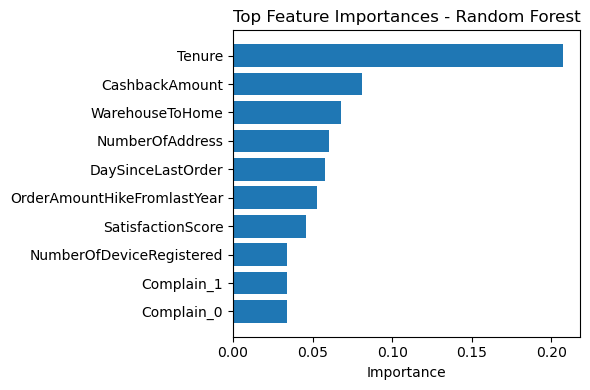

In [64]:
# to display it as a figure 
top_n = 10 # top feature importance set to 10 to display
top_imp = feat_imp.head(top_n).sort_values("importance")

plt.figure(figsize=(6, 4))
plt.barh(top_imp["feature"], top_imp["importance"])
plt.xlabel("Importance")
plt.title("Top Feature Importances - Random Forest")
plt.tight_layout()
plt.show()


#### Here, I plotted the top 10 most important features from the Random Forest model as a horizontal bar chart. This visual summary makes it easier to see which behavioural, transactional and experiential variables have the strongest impact on churn prediction. I use this figure to support the interpretability of my model and to highlight the main churn drivers discussed later in the analysis and linked back to my research question and objectives.

In [66]:
# Taking the three value-related columns
value_features = ["OrderCount", "CashbackAmount", "OrderAmountHikeFromlastYear"]
value_df = df[value_features].copy()

# to impute missing values with the median
val_imputer = SimpleImputer(strategy="median")
value_imputed = val_imputer.fit_transform(value_df)

# Scaling them so they are comparable (z-scores)
val_scaler = StandardScaler()
value_scaled = val_scaler.fit_transform(value_imputed)

# to create individual normalised columns
df["OrderCount_norm"] = value_scaled[:, 0]
df["Cashback_norm"] = value_scaled[:, 1]
df["OrderAmountHike_norm"] = value_scaled[:, 2]

# to combine into a single value proxy (equal weights)
df["ValueProxy"] = (
    df["OrderCount_norm"] +
    df["Cashback_norm"] +
    df["OrderAmountHike_norm"]
) / 3.0

df[["OrderCount", "CashbackAmount", "OrderAmountHikeFromlastYear", "ValueProxy"]].head()

,OrderCount,CashbackAmount,OrderAmountHikeFromlastYear,ValueProxy
0,1.0,160,11.0,-0.777792
1,1.0,121,15.0,-0.670751
2,1.0,120,14.0,-0.770359
3,1.0,134,23.0,0.159995
4,1.0,130,11.0,-0.981088


#### In this step, I created a proxy for customer value using three variables: `OrderCount`, `CashbackAmount` and `OrderAmountHikeFromlastYear`.Firstly I copied these columns into a separate DataFrame, imputed missing values with the median, and then standardised them so they were on a comparable scale. Then I created normalised versions of each component and averaged them to form a single `ValueProxy` score, giving equal weight to frequency and the two monetary-related measures. This ValueProxy acted as an approximate value indicator in my analysis and was later used to define value bands (Low, Mid, High) that support the CLV-oriented, risk-based segmentation in line with my research question and objectives.

In [68]:
df["ValueProxy"].describe()
# summarise the value proxy

count    5630.000000
mean        0.000000
std         0.636525
min        -1.397878
25%        -0.455016
50%        -0.094824
75%         0.331566
max         2.900013
Name: ValueProxy, dtype: float64

#### Here, I have used `df["ValueProxy"].describe()` to obtain summary statistics for the ValueProxy score, including the mean, spread and range. This helped check that the constructed value measure behaved sensibly across customers and provided a basis for later splitting customers into Low, Mid and High value bands in the segmentation analysis. 

#### This notebook’s code was specifically developed to address my research question:
### *How can machine learning–driven churn prediction models be integrated into a risk-based segmentation framework to design targeted retention strategies that maximise customer lifetime value in e-commerce?*

#### First, I built and compared three models (Logistic Regression, Random Forest and Gradient Boosting) on a common preprocessing pipeline and an identical train–test split. Based on Accuracy, Precision, Recall, F1 and ROC AUC, Random Forest performed best and was therefore selected as the final churn model. This addresses the part of my objectives concerned with evaluating and choosing an appropriate machine learning model for churn prediction.

#### Then I used the selected Random Forest to generate churn probabilities for every customer and converted these into three risk bands (Low, Medium and High). This step turned raw model outputs into simple, interpretable risk categories that can support business decisions and directly meets my objective of building a risk-based churn segmentation.

#### Next, I engineered segmentation-related metrics by combining RFM-style and behavioural features in a K-Means clustering model and summarised each cluster in terms of typical behaviour, churn probability and value. In parallel, I constructed a ValueProxy from `OrderCount`, `CashbackAmount` and `OrderAmountHikeFromlastYear` and split customers into Low, Mid and High value bands. Crossing risk bands with clusters and value bands allowed me to highlight segments such as high-risk, high-value customers that would be most critical for targeted retention.

#### Overall, the results show that machine learning–driven churn prediction can be integrated with risk bands, behavioural clusters and value proxies to create a practical risk-based segmentation framework. While the value component is based on proxies rather than full CLV, the framework still aligns with CLV principles by prioritising customers who are both at high risk of churn and economically important. This demonstrates that the modelling pipeline does not just predict churn, but also supports the design of targeted retention strategies in line with my research question and project objectives.
